In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

Matplotlib is building the font cache; this may take a moment.


In [40]:
#import sys
#!{sys.executable} -m pip install matplotlib seaborn scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 28.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 27.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 29.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 37.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [seaborn]1/12 [seaborn]ib]n]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
matches = pd.read_csv('../data/processed/matches_clean.csv')    
worldcup = pd.read_csv('../data/raw/world_cup.csv')

In [3]:
matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unnamed: 0                964 non-null    int64         
 1   home_team                 964 non-null    str           
 2   away_team                 964 non-null    str           
 3   home_score                964 non-null    int64         
 4   away_score                964 non-null    int64         
 5   home_penalty              35 non-null     float64       
 6   away_penalty              35 non-null     float64       
 7   total_goals               964 non-null    int64         
 8   Winner                    964 non-null    str           
 9   Stage                     964 non-null    str           
 10  Year                      964 non-null    int64         
 11  Date                      964 non-null    datetime64[us]
 12  Host                      964 non

In [4]:
matches.head()

,Unnamed: 0,home_team,away_team,home_score,away_score,home_penalty,away_penalty,total_goals,Winner,Stage,...,Date,Host,Venue,Attendance,h_red_card_count,a_red_card_count,h_yellow_red_card_count,a_yellow_red_card_count,h_yellow_card_long_count,a_yellow_card_long_count
0,0,Argentina,France,3,3,4.0,2.0,6,Argentina,Final,...,2022-12-18,Qatar,"Lusail Iconic Stadium, Lusail",88966,0,0,0,0,5,3
1,1,Croatia,Morocco,2,1,NaN,NaN,3,Croatia,Terceiro Lugar,...,2022-12-17,Qatar,"Khalifa International Stadium, Doha",44137,0,0,0,0,0,2
2,2,France,Morocco,2,0,NaN,NaN,2,France,Semi-finais,...,2022-12-14,Qatar,"Al Bayt Stadium, Al Khor",68294,0,0,0,0,0,1
3,3,Argentina,Croatia,3,0,NaN,NaN,3,Argentina,Semi-finais,...,2022-12-13,Qatar,"Lusail Iconic Stadium, Lusail",88966,0,0,0,0,2,2
4,4,Morocco,Portugal,1,0,NaN,NaN,1,Morocco,Quartas de Final,...,2022-12-10,Qatar,"Al Thumama Stadium, ath-Thumāma",44198,0,0,1,0,2,1


In [5]:
worldcup.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Year           22 non-null     int64
 1   Host           22 non-null     str  
 2   Teams          22 non-null     int64
 3   Champion       22 non-null     str  
 4   Runner-Up      22 non-null     str  
 5   TopScorrer     22 non-null     str  
 6   Attendance     22 non-null     int64
 7   AttendanceAvg  22 non-null     int64
 8   Matches        22 non-null     int64
dtypes: int64(5), str(4)
memory usage: 1.7 KB


In [6]:
worldcup.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [7]:
era_bins = [1930, 1970, 2002, 2026]

era_labels = ['Classic Era', 'Modern Era', 'Contemporary Era']

matches ['Era'] = pd.cut(matches['Year'], bins = era_bins, labels = era_labels, include_lowest = True)

In [8]:
teams = pd.unique(
    matches[["home_team", "away_team"]].values.ravel()
)

teams = pd.DataFrame(teams, columns=["Team"])

In [9]:
home_matches = matches.groupby("home_team").size()

away_matches = matches.groupby("away_team").size()

total_matches = home_matches.add(
    away_matches,
    fill_value=0
)

In [10]:
home_wins = matches[
    matches["Winner"] == matches["home_team"]
].groupby("home_team").size()

away_wins = matches[
    matches["Winner"] == matches["away_team"]
].groupby("away_team").size()

total_wins = home_wins.add(
    away_wins,
    fill_value=0
)

In [11]:
teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Team    86 non-null     str  
dtypes: str(1)
memory usage: 820.0 bytes


In [12]:
home_goals = matches.groupby("home_team")["home_score"].sum()

away_goals = matches.groupby("away_team")["away_score"].sum()

goals_scored = home_goals.add(
    away_goals,
    fill_value=0
)

In [13]:
home_conceded = matches.groupby("home_team")["away_score"].sum()

away_conceded = matches.groupby("away_team")["home_score"].sum()

goals_conceded = home_conceded.add(
    away_conceded,
    fill_value=0
)

In [14]:
home_conceded = matches.groupby("home_team")["away_score"].sum()

away_conceded = matches.groupby("away_team")["home_score"].sum()

goals_conceded = home_conceded.add(
    away_conceded,
    fill_value=0
)

In [15]:
team_stats = pd.DataFrame({
    "matches_played": total_matches,
    "wins": total_wins,
    "goals_scored": goals_scored,
    "goals_conceded": goals_conceded
}).fillna(0).reset_index().rename(columns={"index": "Team"})    

In [16]:
team_stats.head(20)

,home_team,matches_played,wins,goals_scored,goals_conceded
0,Algeria,13.0,3.0,13.0,19.0
1,Angola,3.0,0.0,1.0,2.0
2,Argentina,88.0,53.0,152.0,101.0
3,Australia,20.0,4.0,17.0,37.0
4,Austria,29.0,12.0,43.0,47.0
5,Belgium,51.0,22.0,69.0,74.0
6,Bolivia,6.0,0.0,1.0,20.0
7,Bosnia and Herzegovina,3.0,1.0,4.0,4.0
8,Brazil,114.0,79.0,237.0,108.0
9,Bulgaria,26.0,4.0,22.0,53.0


In [17]:
team_stats["win_rate"] = (
    team_stats["wins"] /
    team_stats["matches_played"]
)

In [18]:
team_stats["goal_difference"] = (
    team_stats["goals_scored"] -
    team_stats["goals_conceded"]
)

In [19]:
team_stats["avg_goals_scored"] = (
    team_stats["goals_scored"] /
    team_stats["matches_played"]
)

In [20]:
team_stats["avg_goals_conceded"] = (
    team_stats["goals_conceded"] /
    team_stats["matches_played"]
)

In [21]:
titles = worldcup["Champion"].value_counts()

In [22]:
team_stats["titles"] = (
    team_stats['home_team']
    .map(titles)
    .fillna(0)
)

In [23]:
team_stats.columns

Index(['home_team', 'matches_played', 'wins', 'goals_scored', 'goals_conceded',
       'win_rate', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded',
       'titles'],
      dtype='str')

In [24]:
team_stats.head(15)

,home_team,matches_played,wins,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,titles
0,Algeria,13.0,3.0,13.0,19.0,0.230769,-6.0,1.000000,1.461538,0.0
1,Angola,3.0,0.0,1.0,2.0,0.000000,-1.0,0.333333,0.666667,0.0
2,Argentina,88.0,53.0,152.0,101.0,0.602273,51.0,1.727273,1.147727,3.0
3,Australia,20.0,4.0,17.0,37.0,0.200000,-20.0,0.850000,1.850000,0.0
4,Austria,29.0,12.0,43.0,47.0,0.413793,-4.0,1.482759,1.620690,0.0
5,Belgium,51.0,22.0,69.0,74.0,0.431373,-5.0,1.352941,1.450980,0.0
6,Bolivia,6.0,0.0,1.0,20.0,0.000000,-19.0,0.166667,3.333333,0.0
7,Bosnia and Herzegovina,3.0,1.0,4.0,4.0,0.333333,0.0,1.333333,1.333333,0.0
8,Brazil,114.0,79.0,237.0,108.0,0.692982,129.0,2.078947,0.947368,5.0
9,Bulgaria,26.0,4.0,22.0,53.0,0.153846,-31.0,0.846154,2.038462,0.0


In [25]:
knockout_stages = [
    "Oitavas de Final",
    "Quartas de Final",
    "Semi-finais",
    "Final"
]

knockout_matches = matches[
    matches["Stage"].isin(knockout_stages)
]

In [26]:
knockout_wins = (
    knockout_matches["Winner"]
    .value_counts()
)

In [27]:
home_knockout = knockout_matches["home_team"].value_counts()
away_knockout = knockout_matches["away_team"].value_counts()

knockout_played = home_knockout.add(
    away_knockout,
    fill_value=0
)

In [28]:
team_stats["knockout_matches"] = (
    team_stats["home_team"]
    .map(knockout_played)
    .fillna(0)
)

team_stats["knockout_wins"] = (
    team_stats["home_team"]
    .map(knockout_wins)
    .fillna(0)
)

In [29]:
team_stats["knockout_win_rate"] = (
    team_stats["knockout_wins"]
    / team_stats["knockout_matches"]
)

In [30]:
team_stats["knockout_win_rate"] = (
    team_stats["knockout_win_rate"]
    .fillna(0)
)

In [31]:
team_stats.sort_values(
    by="knockout_win_rate",
    ascending=False
).head(15)

,home_team,matches_played,wins,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,titles,knockout_matches,knockout_wins,knockout_win_rate
40,Italy,83.0,46.0,128.0,77.0,0.554217,51.0,1.542169,0.927711,4.0,29.0,22.0,0.758621
8,Brazil,114.0,79.0,237.0,108.0,0.692982,129.0,2.078947,0.947368,5.0,41.0,29.0,0.707317
28,France,73.0,41.0,136.0,85.0,0.561644,51.0,1.863014,1.164384,2.0,27.0,19.0,0.703704
16,Croatia,30.0,17.0,43.0,33.0,0.566667,10.0,1.433333,1.100000,0.0,10.0,7.0,0.700000
29,Germany,56.0,38.0,126.0,67.0,0.678571,59.0,2.250000,1.196429,2.0,26.0,18.0,0.692308
83,West Germany,56.0,34.0,106.0,63.0,0.607143,43.0,1.892857,1.125000,2.0,19.0,13.0,0.684211
77,Türkiye,10.0,5.0,20.0,17.0,0.500000,3.0,2.000000,1.700000,0.0,3.0,2.0,0.666667
2,Argentina,88.0,53.0,152.0,101.0,0.602273,51.0,1.727273,1.147727,3.0,29.0,19.0,0.655172
4,Austria,29.0,12.0,43.0,47.0,0.413793,-4.0,1.482759,1.620690,0.0,5.0,3.0,0.600000
19,Czechoslovakia,30.0,11.0,44.0,45.0,0.366667,-1.0,1.466667,1.500000,0.0,12.0,7.0,0.583333


In [32]:
matches["total_yellow_cards"] = (
    matches["h_yellow_card_long_count"]
    + matches["a_yellow_card_long_count"]
)

In [33]:
matches["total_red_cards"] = (
    matches["h_red_card_count"]
    + matches["a_red_card_count"]+ matches["a_yellow_red_card_count"]+ matches["h_yellow_red_card_count"]
)

In [34]:
matches["discipline_score"] = (
    matches["total_yellow_cards"]
    + (2 * matches["total_red_cards"])
)

In [35]:
discipline_stats = matches.groupby("home_team").agg({
    "total_yellow_cards": "sum",
    "total_red_cards": "sum",
    "discipline_score": "sum"
}).reset_index()

In [36]:
#discipline_stats.rename(
    #columns={"home_team": "Team"},
    #inplace=True
#)

In [37]:
team_stats = team_stats.merge(
    discipline_stats,
    on="home_team",
    how="left"
)

In [38]:
team_stats.head()

,home_team,matches_played,wins,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,titles,knockout_matches,knockout_wins,knockout_win_rate,total_yellow_cards,total_red_cards,discipline_score
0,Algeria,13.0,3.0,13.0,19.0,0.230769,-6.0,1.000000,1.461538,0.0,1.0,0.0,0.000000,16.0,1.0,18.0
1,Angola,3.0,0.0,1.0,2.0,0.000000,-1.0,0.333333,0.666667,0.0,0.0,0.0,0.000000,5.0,0.0,5.0
2,Argentina,88.0,53.0,152.0,101.0,0.602273,51.0,1.727273,1.147727,3.0,29.0,19.0,0.655172,180.0,10.0,200.0
3,Australia,20.0,4.0,17.0,37.0,0.200000,-20.0,0.850000,1.850000,0.0,2.0,0.0,0.000000,28.0,1.0,30.0
4,Austria,29.0,12.0,43.0,47.0,0.413793,-4.0,1.482759,1.620690,0.0,5.0,3.0,0.600000,19.0,2.0,23.0


In [42]:
team_stats["is_champion"] = np.where(
    team_stats["titles"] > 0,
    1,
    0
)

In [44]:
team_stats.sort_values(
    by="win_rate",
    ascending=False
).head(10)

,home_team,matches_played,wins,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,titles,knockout_matches,knockout_wins,knockout_win_rate,total_yellow_cards,total_red_cards,discipline_score,is_champion
8,Brazil,114.0,79.0,237.0,108.0,0.692982,129.0,2.078947,0.947368,5.0,41.0,29.0,0.707317,191.0,13.0,217.0,1
29,Germany,56.0,38.0,126.0,67.0,0.678571,59.0,2.250000,1.196429,2.0,26.0,18.0,0.692308,111.0,9.0,129.0,1
83,West Germany,56.0,34.0,106.0,63.0,0.607143,43.0,1.892857,1.125000,2.0,19.0,13.0,0.684211,76.0,13.0,102.0,1
2,Argentina,88.0,53.0,152.0,101.0,0.602273,51.0,1.727273,1.147727,3.0,29.0,19.0,0.655172,180.0,10.0,200.0,1
78,Ukraine,5.0,3.0,5.0,7.0,0.600000,-2.0,1.000000,1.400000,0.0,2.0,1.0,0.500000,7.0,1.0,9.0,0
16,Croatia,30.0,17.0,43.0,33.0,0.566667,10.0,1.433333,1.100000,0.0,10.0,7.0,0.700000,27.0,5.0,37.0,0
48,Netherlands,55.0,31.0,96.0,52.0,0.563636,44.0,1.745455,0.945455,0.0,20.0,9.0,0.450000,133.0,7.0,147.0,0
28,France,73.0,41.0,136.0,85.0,0.561644,51.0,1.863014,1.164384,2.0,27.0,19.0,0.703704,103.0,7.0,117.0,1
40,Italy,83.0,46.0,128.0,77.0,0.554217,51.0,1.542169,0.927711,4.0,29.0,22.0,0.758621,139.0,10.0,159.0,1
57,Portugal,35.0,18.0,61.0,41.0,0.514286,20.0,1.742857,1.171429,0.0,9.0,4.0,0.444444,79.0,7.0,93.0,0


In [46]:
team_stats.sort_values(
    by="knockout_win_rate",
    ascending=False
).head(20)

,home_team,matches_played,wins,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,titles,knockout_matches,knockout_wins,knockout_win_rate,total_yellow_cards,total_red_cards,discipline_score,is_champion
40,Italy,83.0,46.0,128.0,77.0,0.554217,51.0,1.542169,0.927711,4.0,29.0,22.0,0.758621,139.0,10.0,159.0,1
8,Brazil,114.0,79.0,237.0,108.0,0.692982,129.0,2.078947,0.947368,5.0,41.0,29.0,0.707317,191.0,13.0,217.0,1
28,France,73.0,41.0,136.0,85.0,0.561644,51.0,1.863014,1.164384,2.0,27.0,19.0,0.703704,103.0,7.0,117.0,1
16,Croatia,30.0,17.0,43.0,33.0,0.566667,10.0,1.433333,1.100000,0.0,10.0,7.0,0.700000,27.0,5.0,37.0,0
29,Germany,56.0,38.0,126.0,67.0,0.678571,59.0,2.250000,1.196429,2.0,26.0,18.0,0.692308,111.0,9.0,129.0,1
83,West Germany,56.0,34.0,106.0,63.0,0.607143,43.0,1.892857,1.125000,2.0,19.0,13.0,0.684211,76.0,13.0,102.0,1
77,Türkiye,10.0,5.0,20.0,17.0,0.500000,3.0,2.000000,1.700000,0.0,3.0,2.0,0.666667,5.0,1.0,7.0,0
2,Argentina,88.0,53.0,152.0,101.0,0.602273,51.0,1.727273,1.147727,3.0,29.0,19.0,0.655172,180.0,10.0,200.0,1
4,Austria,29.0,12.0,43.0,47.0,0.413793,-4.0,1.482759,1.620690,0.0,5.0,3.0,0.600000,19.0,2.0,23.0,0
19,Czechoslovakia,30.0,11.0,44.0,45.0,0.366667,-1.0,1.466667,1.500000,0.0,12.0,7.0,0.583333,5.0,0.0,5.0,0


In [47]:
team_stats["home_team"] = team_stats["home_team"].replace({
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "Yugoslavia": "Serbia",
    "Czechoslovakia": "Czech Republic"
})

In [48]:
team_stats = team_stats.groupby("home_team").sum(numeric_only=True).reset_index()

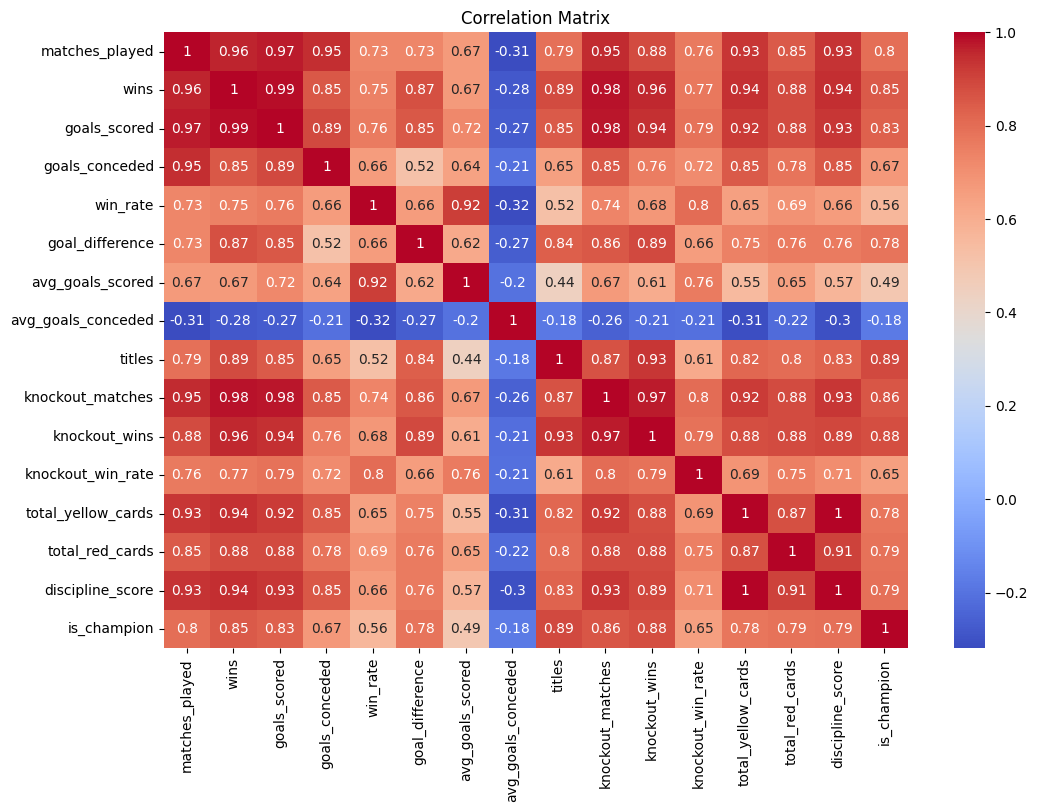

In [49]:
corr = team_stats.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [50]:
features = [
    "win_rate",
    "goal_difference",
    "avg_goals_scored",
    "avg_goals_conceded",
    "knockout_win_rate",
    "titles"
]

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    team_stats[features]
)

In [52]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

team_stats["cluster"] = kmeans.fit_predict(X_scaled)

In [53]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

team_stats["pca1"] = pca_result[:,0]
team_stats["pca2"] = pca_result[:,1]

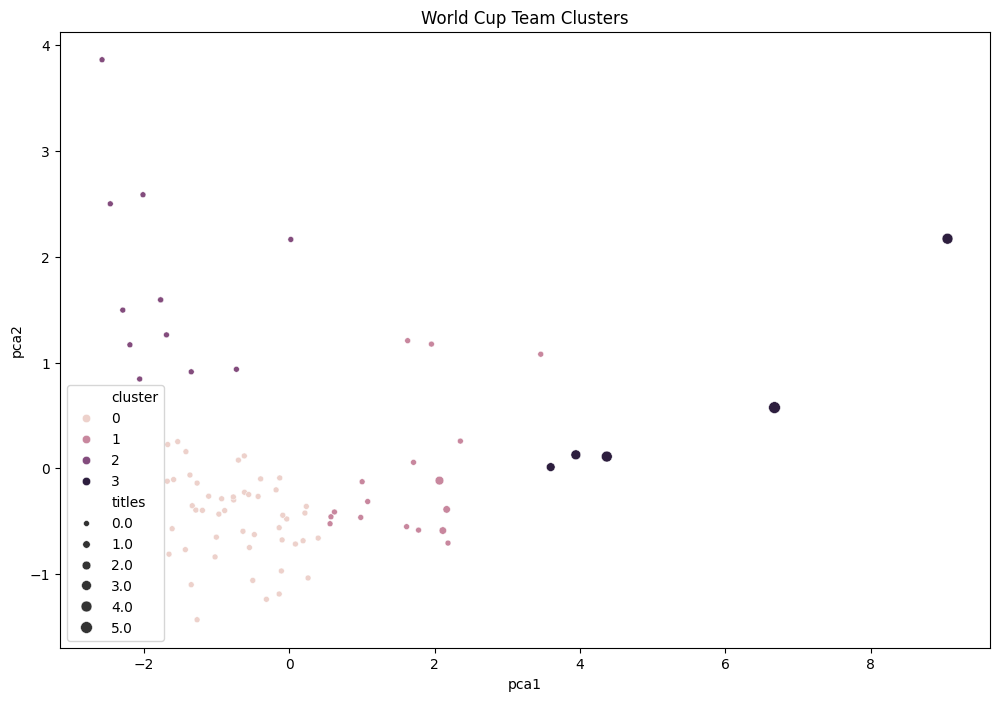

In [54]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=team_stats,
    x="pca1",
    y="pca2",
    hue="cluster",
    size="titles"
)

plt.title("World Cup Team Clusters")
plt.show()

In [88]:
cluster_labels = {
    0: "Emerging Teams",
    1: "Competitive Nations",
    2: "Defensive/Volatile Teams",
    3: "Elite Champions"
}

team_stats["team_profile"] = team_stats["cluster"].map(cluster_labels)

In [55]:
bins = [1930, 1950, 1970, 1990, 2010, 2030]

labels = [
    "Classic Era",
    "Modernizing Era",
    "Tactical Era",
    "Global Era",
    "Modern Football"
]

worldcup["era"] = pd.cut(
    worldcup["Year"],
    bins=bins,
    labels=labels
)

In [56]:
X = team_stats[features]

y = team_stats["is_champion"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [59]:
predictions = model.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1

    accuracy                           0.88        17
   macro avg       0.31      0.33      0.32        17
weighted avg       0.83      0.88      0.85        17



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [60]:
team_stats["champion_probability"] = (
    model.predict_proba(X)[:,1]
)

In [61]:
team_stats.sort_values(
    by="champion_probability",
    ascending=False
)[[
    "home_team",
    "champion_probability",
    "titles",
    "win_rate",
    "knockout_win_rate"
]].head(15)

,home_team,champion_probability,titles,win_rate,knockout_win_rate
39,Italy,1.00,4.0,0.554217,0.758621
27,France,0.95,2.0,0.561644,0.703704
8,Brazil,0.95,5.0,0.692982,0.707317
2,Argentina,0.91,3.0,0.602273,0.655172
28,Germany,0.86,4.0,1.285714,1.376518
79,Uruguay,0.69,2.0,0.440678,0.466667
25,England,0.57,1.0,0.445946,0.500000
69,Spain,0.44,1.0,0.477612,0.470588
47,Netherlands,0.13,0.0,0.563636,0.450000
16,Croatia,0.09,0.0,0.566667,0.700000


In [70]:
modern_wc = matches[
    matches["Year"] >= 2002
].copy()

In [71]:
modern_team_stats = modern_wc.groupby("home_team").agg({
    "home_score": "sum",
    "away_score": "sum",
    "Year": "count"
}).rename(columns={
    "home_score": "goals_scored",
    "away_score": "goals_conceded",
    "Year": "matches_played"
})

modern_team_stats.head()

,goals_scored,goals_conceded,matches_played
home_team,,,
Algeria,1,2,2
Angola,0,1,1
Argentina,36,20,20
Australia,8,10,6
Belgium,22,10,10


In [72]:
modern_team_stats["goals_per_match"] = (
    modern_team_stats["goals_scored"] /
    modern_team_stats["matches_played"]
)

modern_team_stats["goal_balance"] = (
    modern_team_stats["goals_scored"] -
    modern_team_stats["goals_conceded"]
)

In [73]:
modern_team_stats = modern_team_stats.sort_values(
    by="goals_per_match",
    ascending=False
)

modern_team_stats.head(15)

,goals_scored,goals_conceded,matches_played,goals_per_match,goal_balance
home_team,,,,,
Bosnia and Herzegovina,3,1,1,3.000000,2
Türkiye,3,0,1,3.000000,3
Russia,13,4,5,2.600000,9
Portugal,33,10,14,2.357143,23
Belgium,22,10,10,2.200000,12
Spain,30,19,16,1.875000,11
Germany,43,19,23,1.869565,24
Argentina,36,20,20,1.800000,16
Colombia,9,4,5,1.800000,5


In [74]:
modern_team_stats["modern_score"] = (
    modern_team_stats["goals_per_match"] * 0.5 +
    modern_team_stats["goal_balance"] * 0.3 +
    modern_team_stats["matches_played"] * 0.2
)

modern_team_stats = modern_team_stats.sort_values(
    by="modern_score",
    ascending=False
)

modern_team_stats.head(15)

,goals_scored,goals_conceded,matches_played,goals_per_match,goal_balance,modern_score
home_team,,,,,,
Germany,43,19,23,1.869565,24,12.734783
Brazil,43,21,24,1.791667,22,12.295833
Portugal,33,10,14,2.357143,23,10.878571
Argentina,36,20,20,1.800000,16,9.700000
France,30,16,18,1.666667,14,8.633333
Spain,30,19,16,1.875000,11,7.437500
England,24,12,15,1.600000,12,7.400000
Netherlands,21,9,15,1.400000,12,7.300000
Belgium,22,10,10,2.200000,12,6.700000


In [75]:
modern_team_stats = modern_team_stats[
    modern_team_stats["matches_played"] >= 10
]

In [76]:
modern_team_stats = modern_team_stats.sort_values(
    by="modern_score",
    ascending=False
)

modern_team_stats.head(15)

,goals_scored,goals_conceded,matches_played,goals_per_match,goal_balance,modern_score
home_team,,,,,,
Germany,43,19,23,1.869565,24,12.734783
Brazil,43,21,24,1.791667,22,12.295833
Portugal,33,10,14,2.357143,23,10.878571
Argentina,36,20,20,1.800000,16,9.700000
France,30,16,18,1.666667,14,8.633333
Spain,30,19,16,1.875000,11,7.437500
England,24,12,15,1.600000,12,7.400000
Netherlands,21,9,15,1.400000,12,7.300000
Belgium,22,10,10,2.200000,12,6.700000


In [77]:
modern_team_stats["modern_champion"] = 0

In [78]:
champions_modern = [
    "Brazil",
    "Italy",
    "Spain",
    "Germany",
    "France",
    "Argentina"
]

modern_team_stats.loc[
    modern_team_stats.index.isin(champions_modern),
    "modern_champion"
] = 1

In [79]:
features = [
    "goals_scored",
    "goals_conceded",
    "matches_played",
    "goals_per_match",
    "goal_balance",
    "modern_score"
]

X = modern_team_stats[features]

y = modern_team_stats["modern_champion"]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [81]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
modern_team_stats["champion_probability"] = (
    model.predict_proba(X)[:, 1]
)

In [83]:
modern_predictions = modern_team_stats.sort_values(
    by="champion_probability",
    ascending=False
)

modern_predictions[[
    "champion_probability",
    "modern_score",
    "goals_per_match",
    "goal_balance"
]].head(15)

,champion_probability,modern_score,goals_per_match,goal_balance
home_team,,,,
Argentina,0.96,9.700000,1.800000,16
Brazil,0.92,12.295833,1.791667,22
Germany,0.88,12.734783,1.869565,24
France,0.73,8.633333,1.666667,14
Spain,0.31,7.437500,1.875000,11
Portugal,0.30,10.878571,2.357143,23
Belgium,0.04,6.700000,2.200000,12
Korea Republic,0.04,4.133333,1.666667,3
Uruguay,0.03,3.253846,1.307692,0


In [89]:
team_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   home_team             82 non-null     str    
 1   matches_played        82 non-null     float64
 2   wins                  82 non-null     float64
 3   goals_scored          82 non-null     float64
 4   goals_conceded        82 non-null     float64
 5   win_rate              82 non-null     float64
 6   goal_difference       82 non-null     float64
 7   avg_goals_scored      82 non-null     float64
 8   avg_goals_conceded    82 non-null     float64
 9   titles                82 non-null     float64
 10  knockout_matches      82 non-null     float64
 11  knockout_wins         82 non-null     float64
 12  knockout_win_rate     82 non-null     float64
 13  total_yellow_cards    82 non-null     float64
 14  total_red_cards       82 non-null     float64
 15  discipline_score      82 non-null   

In [86]:
modern_team_stats.info()

<class 'pandas.DataFrame'>
Index: 14 entries, Germany to Japan
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   goals_scored          14 non-null     int64  
 1   goals_conceded        14 non-null     int64  
 2   matches_played        14 non-null     int64  
 3   goals_per_match       14 non-null     float64
 4   goal_balance          14 non-null     int64  
 5   modern_score          14 non-null     float64
 6   modern_champion       14 non-null     int64  
 7   champion_probability  14 non-null     float64
dtypes: float64(3), int64(5)
memory usage: 1.5+ KB


In [87]:
modern_predictions.info()

<class 'pandas.DataFrame'>
Index: 14 entries, Argentina to Croatia
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   goals_scored          14 non-null     int64  
 1   goals_conceded        14 non-null     int64  
 2   matches_played        14 non-null     int64  
 3   goals_per_match       14 non-null     float64
 4   goal_balance          14 non-null     int64  
 5   modern_score          14 non-null     float64
 6   modern_champion       14 non-null     int64  
 7   champion_probability  14 non-null     float64
dtypes: float64(3), int64(5)
memory usage: 1.5+ KB


In [ ]:
team_stats[["home_team", "team_profile"]]

SyntaxError: invalid syntax (3138901688.py, line 1)